In [4]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [6]:
DATA_DIR = "/kaggle/input/datasets/gouravanirudh/fashion/processed"
print(os.listdir(DATA_DIR))

['val_labels.pkl', 'validation', 'train_labels.pkl', 'top5.pkl', 'class_weights.pkl', 'train', 'label_map.pkl']


In [7]:
with open(os.path.join(DATA_DIR, "train_labels.pkl"), "rb") as f:
    train_labels = pickle.load(f)

with open(os.path.join(DATA_DIR, "val_labels.pkl"), "rb") as f:
    val_labels = pickle.load(f)

with open(os.path.join(DATA_DIR, "class_weights.pkl"), "rb") as f:
    class_weights = pickle.load(f)

with open(os.path.join(DATA_DIR, "label_map.pkl"), "rb") as f:
    label_map = pickle.load(f)

with open(os.path.join(DATA_DIR, "top5.pkl"), "rb") as f:
    top5_classes = pickle.load(f)

NUM_CLASSES = len(top5_classes)

print("Classes:", top5_classes)

Classes: [1, 8, 7, 2, 9]


In [8]:
label_map_json = {cls:i for i,cls in enumerate(top5_classes)}

with open("/kaggle/working/label_map.json","w") as f:
    json.dump(label_map_json,f,indent=4)

print(label_map_json)

{1: 0, 8: 1, 7: 2, 2: 3, 9: 4}


In [9]:
train_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2,contrast=0.2),
    transforms.ToTensor()
])

val_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [10]:
class ApparelDataset(Dataset):
    def __init__(self, image_dir, labels_dict, transform=None):
        self.image_dir = image_dir
        self.labels_dict = labels_dict
        self.images = list(labels_dict.keys())
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.image_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        label = torch.tensor(self.labels_dict[img_name]).float()

        if self.transform:
            image = self.transform(image)

        return image, label

In [11]:
label_matrix = np.array(list(train_labels.values()))

class_counts = label_matrix.sum(axis=0)

class_weights = 1.0/(class_counts + 1e-6)

sample_weights = (label_matrix * class_weights).sum(axis=1)

sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    sample_weights,
    len(sample_weights),
    replacement=True
)

print("Class counts:", class_counts)

Class counts: [70586. 54969. 36332. 35751. 30625.]


In [12]:
train_dir = os.path.join(DATA_DIR,"train")

print("Example label keys:")
print(list(train_labels.keys())[:10])

print("\nExample train images:")
print(os.listdir(train_dir)[:10])

Example label keys:
['101169.jpg', '186690.jpg', '134125.jpg', '049464.jpg', '091880.jpg', '187305.jpg', '104255.jpg', '142055.jpg', '019279.jpg', '025643.jpg']

Example train images:
['annos', 'images']


In [13]:
train_dataset = ApparelDataset(
    os.path.join(DATA_DIR,"train","images"),
    train_labels,
    train_tfms
)

val_dataset = ApparelDataset(
    os.path.join(DATA_DIR,"validation","images"),
    val_labels,
    val_tfms
)

print("Train size:",len(train_dataset))
print("Val size:",len(val_dataset))

Train size: 144174
Val size: 23741


In [14]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [15]:
model = models.mobilenet_v3_large(weights=None)

model.classifier[3] = nn.Linear(
    model.classifier[3].in_features,
    NUM_CLASSES
)

model = model.to(device)

print("Model ready")

Model ready


In [16]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [17]:
EPOCHS = 10
best_f1 = -1   # important fix

for epoch in range(EPOCHS):

    # ---------------- TRAIN ----------------
    model.train()
    train_loss = 0

    for images,labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs,labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    print(f"\nEpoch {epoch}")
    print("Train Loss:", train_loss)

    # ---------------- VALIDATION ----------------
    model.eval()

    preds = []
    targets = []

    with torch.no_grad():

        for images,labels in tqdm(val_loader):

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs).cpu().numpy()

            preds.append(probs)
            targets.append(labels.numpy())

    preds = np.vstack(preds)
    targets = np.vstack(targets)

    preds_binary = (preds > 0.5).astype(int)

    macro_f1 = f1_score(targets, preds_binary, average="macro")

    print("Validation Macro F1:", macro_f1)

    # ---------------- SAVE BEST MODEL ----------------
    if macro_f1 > best_f1:

        print("Saving best model...")

        best_f1 = macro_f1

        torch.save(
            model.state_dict(),
            "/kaggle/working/best_model.pth"
        )

100%|██████████| 4506/4506 [18:45<00:00,  4.00it/s]



Epoch 0
Train Loss: 0.5503536302793095


100%|██████████| 742/742 [03:05<00:00,  4.00it/s]


Validation Macro F1: 0.5350351131619804
Saving best model...


100%|██████████| 4506/4506 [15:58<00:00,  4.70it/s]


...

Validation Macro F1: 0.7640138893937236


100%|██████████| 4506/4506 [13:43<00:00,  5.47it/s]



Epoch 9
Train Loss: 0.2733519011575198


100%|██████████| 742/742 [01:49<00:00,  6.77it/s]

Validation Macro F1: 0.7711483357133376
Saving best model...


In [18]:
precision = precision_score(targets, preds_binary, average=None)
recall = recall_score(targets, preds_binary, average=None)
f1 = f1_score(targets, preds_binary, average=None)

print("\nPer-Class Metrics\n")

for i, cls in enumerate(top5_classes):
    print(cls)
    print("Precision:", precision[i])
    print("Recall:", recall[i])
    print("F1:", f1[i])
    print()

macro_f1 = f1_score(targets, preds_binary, average="macro")
micro_f1 = f1_score(targets, preds_binary, average="micro")

print("Macro F1:", macro_f1)
print("Micro F1:", micro_f1)


Per-Class Metrics

1
Precision: 0.8744374024065399
Recall: 0.7695416700347587
F1: 0.81864304755353

8
Precision: 0.864021773264943
Recall: 0.8693911944385928
F1: 0.8666981676904499

7
Precision: 0.7748156551332955
Recall: 0.6610210500846843
F1: 0.7134090612351482

2
Precision: 0.5802425938885001
Recall: 0.8409398242055443
F1: 0.6866804692891649

9
Precision: 0.7725162488393686
Recall: 0.7681181720264656
F1: 0.7703109327983951

Macro F1: 0.7711483357133376
Micro F1: 0.7872634502357424


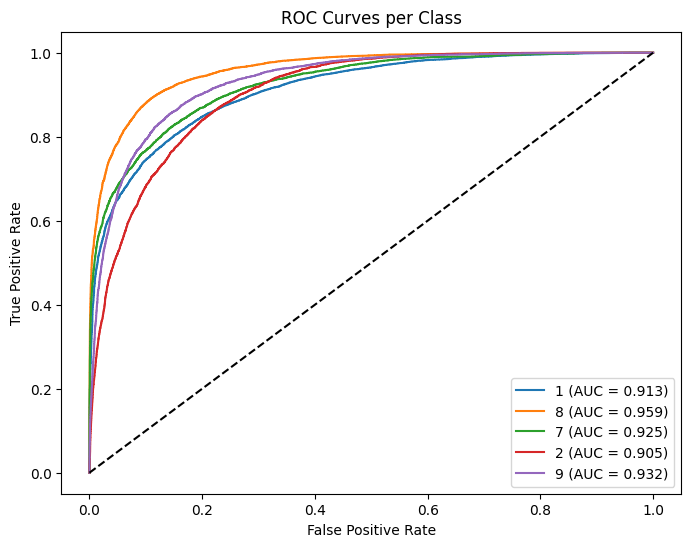

In [19]:
plt.figure(figsize=(8,6))

for i, cls in enumerate(top5_classes):
    fpr, tpr, _ = roc_curve(targets[:,i], preds[:,i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{cls} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves per Class")

plt.legend()
plt.show()

In [20]:
# if macro_f1 > best_f1:
#     best_f1 = macro_f1

#     torch.save(
#         model.state_dict(),
#         "/kaggle/working/best_model.pth"
#     )

#     print("Saved best model")

In [21]:
import os
print(os.listdir("/kaggle/working"))

['best_model.pth', '.virtual_documents', 'label_map.json']
